import libs

In [72]:
import os
from datetime import datetime
import pandas as pd
import urllib.request
import numpy as np
from scipy import stats
import timeit
import seaborn as sns
import matplotlib.pyplot as plt
print ('Done!')

Done!


Частина 2 \
Завантажити та відкрити (вручну або через запропонований скрипт на сайті) наступний датасет: Individual Household Electric Power Consumption Dataset
https://archive.ics.uci.edu/dataset/235/individual%2Bhousehold%2Belectric%2Bpower%2Bconsumption

In [73]:
hh_df = pd.read_csv("household_power_consumption.txt", index_col=False, sep=';', na_values=['?'])
print("Відкрито датасет:")
display(hh_df.head())

Відкрито датасет:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Здійснити data cleaning

In [74]:
def clear_data(hh_df):
    # change type of columns with numbers to float type
    cols_fix_type = ['Global_active_power', 'Global_reactive_power', 'Voltage','Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
    hh_df[cols_fix_type] = hh_df[cols_fix_type].astype(float)
    # fill missing numbers (presented here as '?') with interpolation, so we wont have empty time gaps (every next row is 1 minute further in time)
    # especially, because we have 2.5 days (28-30/4/2007) of missing values, which is like 3600 empty rows
    hh_df[cols_fix_type] = hh_df[cols_fix_type].interpolate(method='linear')
    # change type of columns with time and date to time and date type
    hh_df['Time'] = pd.to_datetime(hh_df['Time'], format='%H:%M:%S').dt.time
    hh_df['Date'] = pd.to_datetime(hh_df['Date'], format='%d/%m/%Y').dt.date
    return (hh_df)
hh_df = clear_data(hh_df)
print ('Очищений датасет:')
display(hh_df.head())

Очищений датасет:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Окремими функціями сформувати вибірки: \
1.Обрати всі записи, у яких загальна активна споживана потужність перевищує 5 кВт. \
2.Обрати всі записи, у яких сила струму лежить в межах 19-20 А, для них виявити ті, у яких пральна машина та холодильних споживають більше, ніж бойлер та кондиціонер.\
3.Обрати випадковим чином 500000 записів (без повторів елементів вибірки), для них обчислити середні величини усіх 3-х груп споживання електричної енергії.\
4.Обрати ті записи, які після 18-00 споживають понад 6 кВт за хвилину в середньому, серед відібраних визначити ті, у яких основне споживання електроенергії у вказаний проміжок часу припадає на пральну машину, сушарку, холодильник та освітлення (група 2 є найбільшою), а потім обрати кожен третій результат із першої половини та кожен четвертий результат із другої половини.\
\
Series for:\
1.Select all records where the total active power consumption exceeds 5 kW\
2.Select all records in which the current strength is within 19-20 A, and for them, identify those in which the washing machine and refrigerator consume more than the boiler and air conditioner.\
3.Randomly select 500,000 records (without repeating sample elements), and calculate the average values of all 3 groups of electricity consumption for them.\
4.Select those records that consume more than 6 kW per minute on average after 6:00 PM, among the selected ones, determine those in which the main electricity consumption during the specified period of time is for the washing machine, dryer, refrigerator and lighting (group 2 is the largest), and then select every third result from the first half and every fourth result from the second half.

In [62]:
# 1.Обрати всі записи, у яких загальна активна споживана потужність перевищує 5 кВт.
def task1 (df):
    return df[df['Global_active_power'] > 5]

In [39]:
print('всі записи, у яких загальна активна споживана потужність перевищує 5 кВт:')
display(task1(hh_df).head())

всі записи, у яких загальна активна споживана потужність перевищує 5 кВт:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
11,2006-12-16,17:35:00,5.412,0.470,232.78,23.2,0.0,1.0,17.0
12,2006-12-16,17:36:00,5.224,0.478,232.99,22.4,0.0,1.0,16.0


In [40]:
# 2.Обрати всі записи, у яких сила струму лежить в межах 19-20 А, для них виявити ті, у яких пральна машина та холодильних споживають більше, 
# ніж бойлер та кондиціонер.
def task2(df):
    return df[(df['Global_intensity'] >= 19) & (df['Global_intensity'] <= 20) & (df['Sub_metering_2'] > df['Sub_metering_3'])]

In [41]:
print('всі записи, у яких сила струму лежить в межах 19-20 А, для них виявити ті, у яких пральна машина та холодильних споживають більше, ніж бойлер та кондиціонер:')
display(task2(hh_df).head())

всі записи, у яких сила струму лежить в межах 19-20 А, для них виявити ті, у яких пральна машина та холодильних споживають більше, ніж бойлер та кондиціонер:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
45,2006-12-16,18:09:00,4.464,0.136,234.66,19.0,0.0,37.0,16.0
460,2006-12-17,01:04:00,4.582,0.258,238.08,19.6,0.0,13.0,0.0
464,2006-12-17,01:08:00,4.618,0.104,239.61,19.6,0.0,27.0,0.0
475,2006-12-17,01:19:00,4.636,0.140,237.37,19.4,0.0,36.0,0.0
476,2006-12-17,01:20:00,4.634,0.152,237.17,19.4,0.0,35.0,0.0


In [42]:
# 3.Обрати випадковим чином 500000 записів (без повторів елементів вибірки), для них обчислити середні величини усіх 3-х груп 
# споживання електричної енергії.
def task3(df):
    sample = df.sample(n=500000)
    return({'Sub_metering_1_mean': sample['Sub_metering_1'].mean(),'Sub_metering_2_mean': sample['Sub_metering_2'].mean(),
             'Sub_metering_3_mean': sample['Sub_metering_3'].mean()})

In [43]:
means = task3(hh_df)
print('Для випадкових 500000 записів:')
print(f"Sub_metering_1_mean: {means['Sub_metering_1_mean']}\nSub_metering_2_mean: {means['Sub_metering_2_mean']}\nSub_metering_3_mean: {means['Sub_metering_3_mean']}")

Для випадкових 500000 записів:
Sub_metering_1_mean: 1.1150897533546325
Sub_metering_2_mean: 1.2866673757137768
Sub_metering_3_mean: 6.417033068620294


In [44]:
#4.Обрати ті записи, які після 18-00 споживають понад 6 кВт за хвилину в середньому, серед відібраних визначити ті, у яких основне споживання 
# електроенергії у вказаний проміжок часу припадає на пральну машину, сушарку, холодильник та освітлення (група 2 є найбільшою), а потім обрати кожен 
# третій результат із першої половини та кожен четвертий результат із другої половини.
def task4(df):
    time = pd.to_datetime('18:00:00', format='%H:%M:%S').time()
    df = df[(df['Time'] > time) & (df['Global_active_power'] > 6) & \
        (df['Sub_metering_2'] > df['Sub_metering_1']) & (df['Sub_metering_2'] > df['Sub_metering_3'])]
    half = len(df)//2
    first_half = df.iloc[:half:3]
    second_half = df.iloc[half:4]
    return (pd.concat([first_half,second_half]))

In [45]:
print ("Завдання 4:")
display(task4(hh_df))

Завдання 4:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
41,2006-12-16,18:05:00,6.052,0.192,232.93,26.2,0.0,37.0,17.0
44,2006-12-16,18:08:00,6.308,0.116,232.25,27.0,0.0,36.0,17.0
17494,2006-12-28,20:58:00,6.386,0.374,236.63,27.0,1.0,36.0,17.0
17498,2006-12-28,21:02:00,8.088,0.262,235.50,34.4,1.0,72.0,17.0
17501,2006-12-28,21:05:00,7.230,0.152,235.22,30.6,1.0,73.0,17.0
...,...,...,...,...,...,...,...,...,...
666906,2008-03-23,20:30:00,6.952,0.178,234.24,29.6,0.0,72.0,17.0
666909,2008-03-23,20:33:00,6.490,0.196,234.04,27.6,0.0,72.0,17.0
666912,2008-03-23,20:36:00,6.708,0.180,234.10,28.6,0.0,73.0,16.0
707256,2008-04-20,21:00:00,8.268,0.312,232.30,35.6,1.0,72.0,17.0


Пронормувати та стандартизувати вибраний датасет \
Normalize and standardize the selected dataset

In [76]:
def norm(hh_df):
    norm_cols=['Global_active_power','Global_reactive_power','Global_intensity']
    df = hh_df.copy()
    for col in norm_cols:
        df[col], _ = stats.boxcox(df[col]+0.001)
        #print(f'done: {col}')
    return (df)
normalized_df = norm (hh_df)

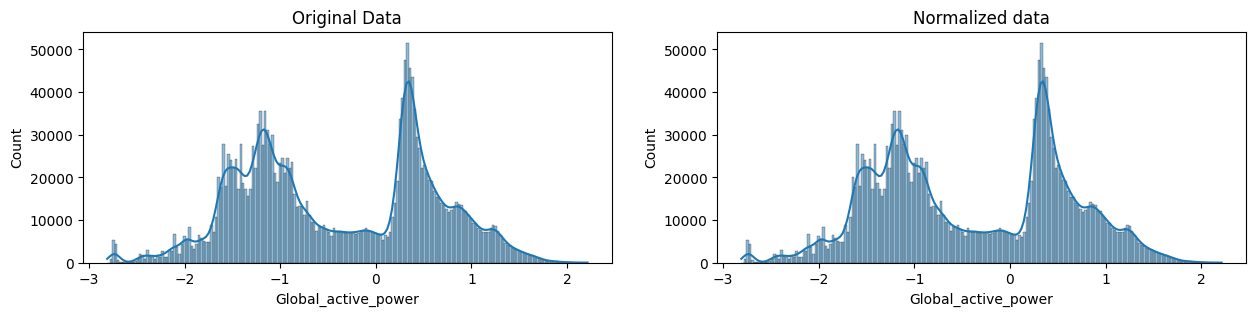

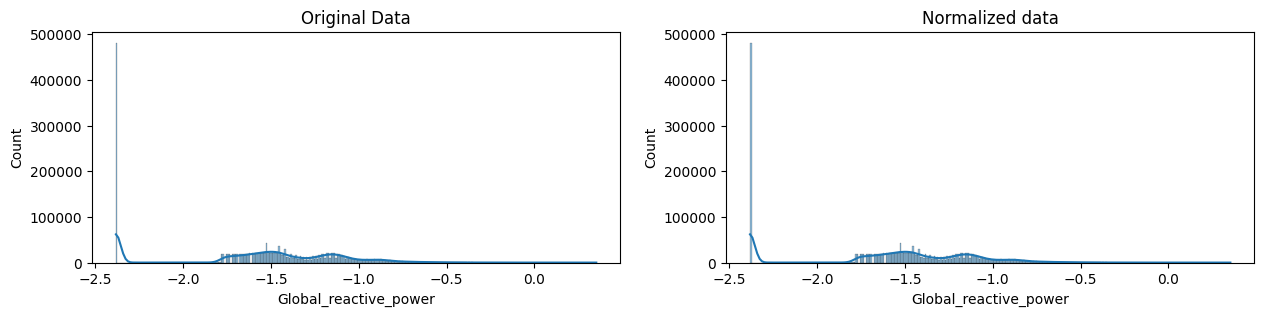

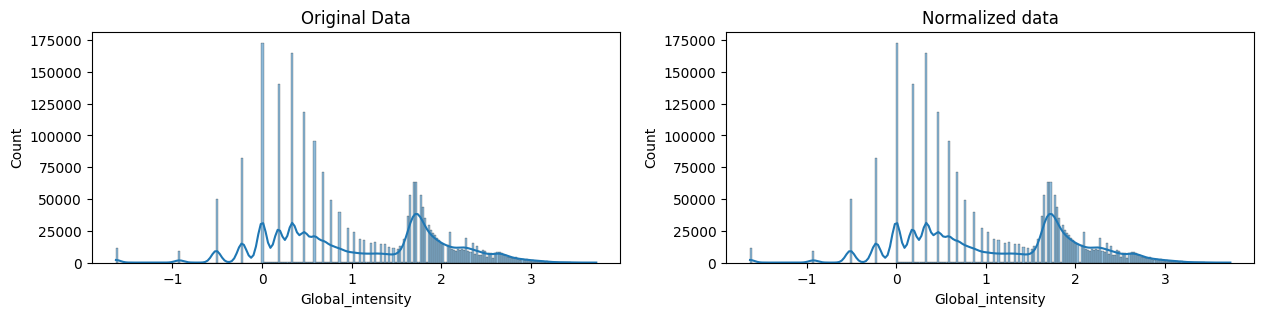

In [47]:
# show data with plt
for col in norm_cols:
    fig, ax=plt.subplots(1, 2, figsize=(15, 3))
    sns.histplot(hh_df[col], ax=ax[0], kde=True)
    ax[0].set_title("Original Data")
    sns.histplot(normalized_df[col], ax=ax[1], kde=True)
    ax[1].set_title("Normalized data")
    plt.show()

Підрахувати коефіцієнт Пірсона та Спірмена для двох integer/real атрибутів.\
Calculate the Pearson and Spearman coefficients for two integer/real attributes.

In [34]:
# Global_active_power and Global_intensity was choosen as attributes, because their plots were similar (+ relation between W and V)
# Global_active_power і Global_intensity були обрані як атрибути, бо їх графіки схожі (+ відношення Вт та В по формулі)
def correl(hh_df,normalized_df):
    attr1 = 'Global_active_power'
    attr2 = 'Global_intensity'
    p_correl = hh_df[attr1].corr(hh_df[attr2], method='pearson')
    s_correl = hh_df[attr1].corr(hh_df[attr2], method='spearman')
    p_correl_norm = normalized_df[attr1].corr(normalized_df[attr2], method='pearson')
    s_correl_norm = normalized_df[attr1].corr(normalized_df[attr2], method='spearman')
    print (f"Pearson correlation: {p_correl:.4f}, on normalized data: {p_correl_norm:.4f}")
    print (f"Spierman correlation: {s_correl:.4f}, on normalized data: {s_correl_norm:.4f}")
correl(hh_df,normalized_df)

Pearson correlation: 0.9989, on normalized data: 0.9959
Spierman correlation: 0.9955, on normalized data: 0.9955


Провести One Hot Encoding категоріального атрибута.\
Perform One Hot Encoding of the categorical attribute.

In [25]:
# As categorical attribute choosen "time"
# За категоріальний артибут взято "time"
def get_period(hour):
    if 0<=hour<=6 :return 'Night'
    if 6<=hour<=12 :return 'Morning'
    if 12<=hour<=18 :return 'Day'
    return 'Evening'
def catt_time(df):
    df['Day_Period'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour.apply(get_period)
    df_encoded = pd.get_dummies(df, columns=['Day_Period'], prefix='Period')
    return df_encoded

In [26]:
print ("One Hot Encoding категоріального атрибута:")
display(catt_time(hh_df).head())

One Hot Encoding категоріального атрибута:


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Period_Day,Period_Evening,Period_Morning,Period_Night
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,True,False,False,False
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,True,False,False,False
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,True,False,False,False
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,True,False,False,False
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,True,False,False,False


Проаналізувати часові витрати на виконання процедур (профілювання часу виконання здійснити за допомогою модуля timeit).

In [77]:
functions = ["clear_data(hh_df)", "task1(hh_df)","task2(hh_df)","task3(hh_df)","task4(hh_df)", "norm(hh_df)", "correl(hh_df,normalized_df)", "catt_time(hh_df)"]
times = []
for func in functions:
    t = timeit.repeat(func,globals=globals(), number=1, repeat=5)
    print (f"Для функції {func}: \nСередній час - {(sum(t)/len(t)):.5f} секунд\nНайкращий час - {min(t):.5f} секунд")


Для функції clear_data(hh_df): 
Середній час - 8.97063 секунд
Найкращий час - 8.77810 секунд
Для функції task1(hh_df): 
Середній час - 0.00576 секунд
Найкращий час - 0.00503 секунд
Для функції task2(hh_df): 
Середній час - 0.01580 секунд
Найкращий час - 0.01258 секунд
Для функції task3(hh_df): 
Середній час - 0.24162 секунд
Найкращий час - 0.22753 секунд
Для функції task4(hh_df): 
Середній час - 0.13745 секунд
Найкращий час - 0.12681 секунд
Для функції norm(hh_df): 
Середній час - 33.64738 секунд
Найкращий час - 33.10428 секунд
Pearson correlation: 0.9989, on normalized data: 0.9959
Spierman correlation: 0.9955, on normalized data: 0.9955
Pearson correlation: 0.9989, on normalized data: 0.9959
Spierman correlation: 0.9955, on normalized data: 0.9955
Pearson correlation: 0.9989, on normalized data: 0.9959
Spierman correlation: 0.9955, on normalized data: 0.9955
Pearson correlation: 0.9989, on normalized data: 0.9959
Spierman correlation: 0.9955, on normalized data: 0.9955
Pearson correl